In [1]:
%pip install -q langchain langchain_groq langchain_community langgraph

Note: you may need to restart the kernel to use updated packages.


In [ ]:
groq_api_key = ".."
langsmith=".."

In [3]:
import os
os.environ['LANGCHAIN_API_KEY']=langsmith
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT']='LiveLangraph'

In [4]:
from langchain_groq import ChatGroq

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm=ChatGroq(api_key=groq_api_key,model_name='llama-3.1-8b-instant')

In [6]:
import pandas as pd
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
  #message have the type "list". The 'add_messages' function
  #in the annotation defines how this state key should be updated
  messages:Annotated[list,add_messages]
  dataset:pd.DataFrame

graph_builder=StateGraph(State)

In [8]:
data=pd.read_csv('crop_yield_prediction_data_crop_yield.csv')

In [9]:
# Add dataset to initial state
initial_state = {"messages": [], "dataset": data}

In [10]:
def chatbot(state: State):
    # Get the user's latest message
    user_message = state["messages"][-1] if state["messages"] else "Hello!"

    # Generate context for the LLM
    dataset_summary = {
        "columns": state["dataset"].columns.tolist(),
        "row_count": len(state["dataset"]),
        "missing_values": state["dataset"].isnull().sum().to_dict(),
        "summary_statistics": state["dataset"].describe().to_dict(),
    }

    # Prepare the LLM prompt
    prompt = f"""
You are an intelligent assistant for analyzing datasets.
Here is a summary of the dataset:
- Columns: {dataset_summary['columns']}
- Row Count: {dataset_summary['row_count']}
- Missing Values: {dataset_summary['missing_values']}
- Summary Statistics: {dataset_summary['summary_statistics']}

The user has asked the following question: "{user_message}"

Provide a helpful response.
"""

    # Invoke the LLM to generate a response
    response = llm.invoke(prompt)

    # Return the response as part of the updated state
    return {"messages": [response]}


In [11]:
graph_builder.add_node("chatbot", chatbot)

In [12]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [13]:
graph = graph_builder.compile()

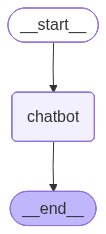

In [14]:
graph

In [15]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({**initial_state, "messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

# Simulate predefined queries
user_queries = [
    "Summarize the dataset",
    "Find the missing values",
    "Show the correlation matrix",
    "What are the columns in the dataset?",
    "How many rows are in the dataset?"
]

# Process each query using streaming
for query in user_queries:
    print(f"User Query: {query}")
    stream_graph_updates(query)
    print("\n")


User Query: Summarize the dataset
Assistant: Based on the provided dataset summary, I will provide a summary of the dataset.

**Dataset Summary**

The dataset contains 63 rows and 11 columns. The columns include 'year', 'state', 'crop', 'area_hectare', 'rainfall_mm', 'temperature_c', 'fertilizer_kg_per_hectare', 'pesticide_kg_per_hectare', 'soil_ph', 'irrigated', and 'yield_ton_per_hectare'.

**Missing Values**

There is one missing value in the 'year' column, and one missing value in the 'area_hectare' column.

**Summary Statistics**

Here are the summary statistics for each column:

- **year**: The year ranges from 2019 to 2024 with a mean of 2022.48 and a standard deviation of 1.68.
- **area_hectare**: The area in hectares ranges from 1.8 to 4.4 with a mean of 3.10 and a standard deviation of 0.66.
- **rainfall_mm**: The rainfall in millimeters ranges from 380 to 2300 with a mean of 828 and a standard deviation of 275.
- **temperature_c**: The temperature in degrees Celsius ranges f